In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel('business_metrics_dataset.xlsx')

In [3]:
df.head()

,Month,Amount Invested,Net Profit,Total Revenue,Number of Orders,Marketing & Sales Costs,New Customers,Customers at Start,Customers Lost,Customers at End,...,Average Monthly Revenue per Customer,Available Cash,Monthly Cash Outflows,Monthly Cash Inflows,Net Income,Interest Expense,Income Taxes,Depreciation,Amortization,Gross Operating Costs
0,2025-01-01,100000,134050.30,451116.53,667,89756.22,51,420,10,461,...,1063.82,1719050.30,332066.23,551116.53,134050.30,8286.06,29425.68,13479.36,4975.19,279354.49
1,2025-02-01,0,162072.30,526769.13,680,85772.39,60,461,13,508,...,1090.59,1881122.60,364696.83,526769.13,162072.30,7813.82,35576.85,14758.68,5185.83,321306.16
2,2025-03-01,0,192976.50,617722.11,742,88946.39,60,508,12,556,...,1113.52,2074099.10,424745.61,617722.11,192976.50,8043.80,42360.70,14116.01,5331.52,374341.11
3,2025-04-01,0,195238.90,603250.13,779,92394.71,73,556,17,612,...,1094.93,2269338.00,408011.23,603250.13,195238.90,8725.70,42857.32,14517.67,5444.91,356428.21
4,2025-05-01,0,223499.08,707681.15,798,102047.64,78,612,17,673,...,1108.87,2492837.08,484182.07,707681.15,223499.08,8788.33,49060.77,15455.49,5299.88,426332.97


In [4]:
df.describe().round(2)

,Month,Amount Invested,Net Profit,Total Revenue,Number of Orders,Marketing & Sales Costs,New Customers,Customers at Start,Customers Lost,Customers at End,...,Average Monthly Revenue per Customer,Available Cash,Monthly Cash Outflows,Monthly Cash Inflows,Net Income,Interest Expense,Income Taxes,Depreciation,Amortization,Gross Operating Costs
count,24,24.00,24.00,24.00,24.00,24.00,24.00,24.00,24.00,24.00,...,24.00,24.00,24.00,24.00,24.00,24.00,24.00,24.00,24.00,24.00
mean,2025-12-16 00:00:00,16666.67,406258.14,1277854.57,1088.46,125129.94,103.21,1151.33,30.67,1223.88,...,1260.98,5483816.81,874096.43,1294521.24,406258.14,10852.15,89178.62,17301.84,6374.93,771565.67
min,2025-01-01 00:00:00,0.00,134050.30,451116.53,667.00,85772.39,51.00,420.00,10.00,461.00,...,1063.82,1719050.30,332066.23,526769.13,134050.30,7813.82,29425.68,13479.36,4975.19,279354.49
25%,2025-06-23 12:00:00,0.00,252147.12,810418.69,871.50,106228.66,79.75,722.50,18.50,784.00,...,1155.92,2990875.08,555300.97,814445.94,252147.12,9315.04,55349.37,15377.40,5627.50,488651.86
50%,2025-12-16 12:00:00,0.00,363090.38,1140230.00,1088.00,126333.98,98.50,1115.50,29.50,1185.00,...,1261.47,4851112.18,791034.48,1190230.00,363090.38,10806.99,79702.76,17124.84,6392.48,694522.56
75%,2026-06-08 12:00:00,0.00,543700.44,1707421.98,1301.75,142035.00,126.00,1540.75,41.50,1627.00,...,1367.11,7571417.88,1166836.28,1717967.51,543700.44,12416.78,119348.88,19323.90,7150.91,1031017.55
max,2026-12-01 00:00:00,100000.00,807522.44,2535278.64,1502.00,168543.61,151.00,2061.00,54.00,2161.00,...,1477.89,11590195.37,1727756.20,2535278.64,807522.44,14034.76,177261.02,20898.59,7564.57,1536460.42
std,NaN,38069.35,197434.50,597585.77,268.36,25112.93,29.28,507.17,14.13,522.30,...,128.77,3007303.08,399845.87,592482.13,197434.50,1880.93,43339.28,2253.83,825.66,355808.35


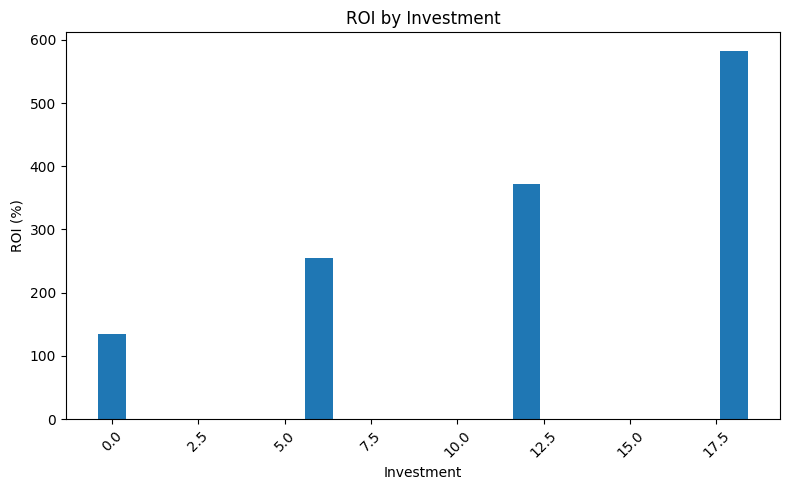

In [5]:
ROI_data = (df['Net Profit'] / df['Amount Invested']) * 100

plt.figure(figsize=(8, 5))
plt.bar(df.index, ROI_data)

plt.xlabel('Investment')
plt.ylabel('ROI (%)')
plt.title('ROI by Investment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
runway = df['Available Cash'] / (df['Monthly Cash Inflows'] - df['Monthly Cash Outflows'])

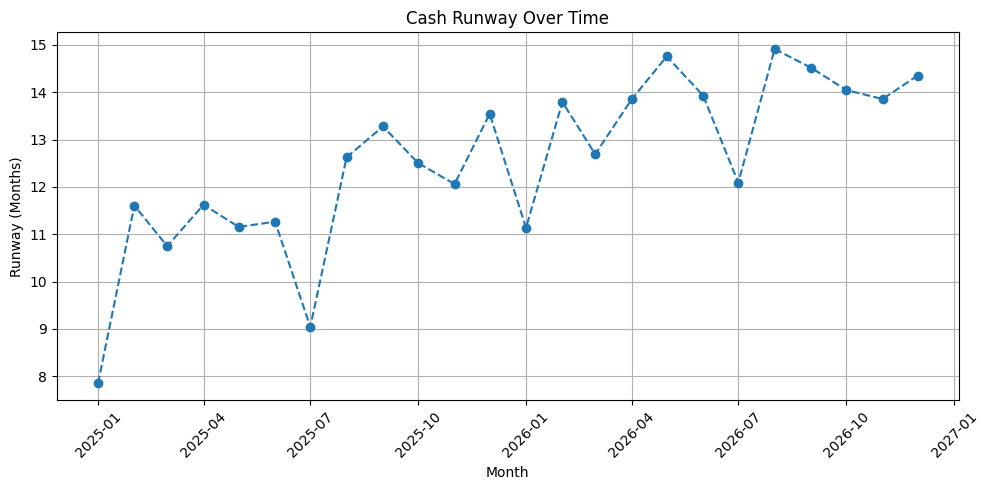

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(df['Month'], runway, marker='o', linestyle = '--') 

plt.xlabel('Month')
plt.ylabel('Runway (Months)')
plt.title('Cash Runway Over Time')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

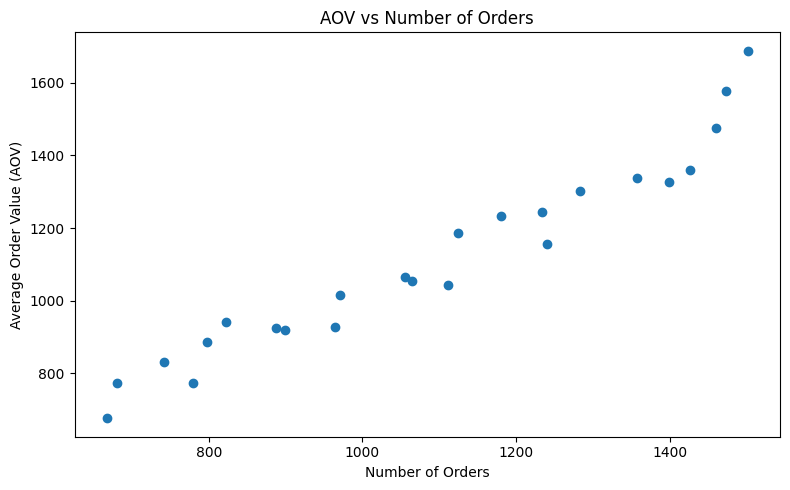

In [21]:
AOV = df['Total Revenue'] / df['Number of Orders']

plt.figure(figsize=(8, 5))

plt.scatter(df['Number of Orders'], AOV)

plt.xlabel('Number of Orders')
plt.ylabel('Average Order Value (AOV)')
plt.title('AOV vs Number of Orders')
plt.tight_layout()
plt.show()

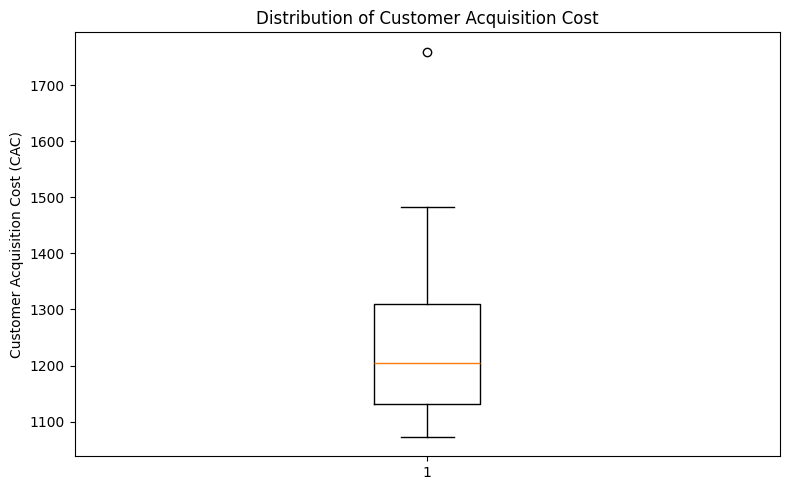

In [25]:
CAC = df['Marketing & Sales Costs'] / df['New Customers']

plt.figure(figsize=(8, 5))

plt.boxplot(CAC.dropna())

plt.ylabel('Customer Acquisition Cost (CAC)')
plt.title('Distribution of Customer Acquisition Cost')

plt.tight_layout()
plt.show()

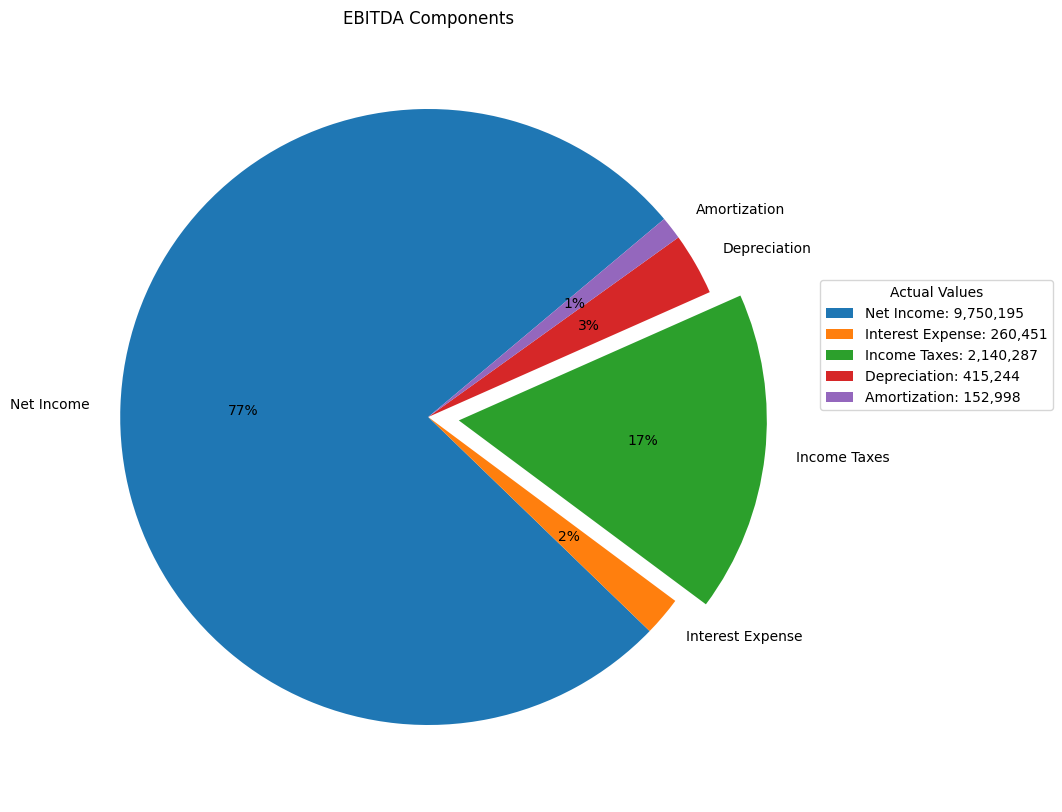

In [68]:
EBITDA = (
    df['Net Income']
    + df['Interest Expense']
    + df['Income Taxes']
    + df['Depreciation']
    + df['Amortization']
)

plt.figure(figsize=(10, 10))

plt.pie(
    [
        df['Net Income'].sum(),
        df['Interest Expense'].sum(),
        df['Income Taxes'].sum(),
        df['Depreciation'].sum(),
        df['Amortization'].sum()
    ],
    labels=[
        'Net Income',
        'Interest Expense',
        'Income Taxes',
        'Depreciation',
        'Amortization'
    ],
    autopct='%1.0f%%', startangle = 40, textprops={'fontsize':10}, 
    explode=[0, 0, 0.1, 0, 0]
)
legend_labels = [
    f'{label}: {value:,.0f}'
    for label, value in zip(labels, values)
]
plt.legend(
    legend_labels,
    title='Actual Values',
    loc='best',
    bbox_to_anchor=(1, 0.5)
)
plt.title('EBITDA Components')
plt.show()